## 0. Installs & Imports

In [1]:
# !pip install h2o pandas requests matplotlib seaborn

import io, os, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests

import h2o
from h2o.automl import H2OAutoML

warnings.filterwarnings('ignore')
print('h2o version:', h2o.__version__)

h2o version: 3.46.0.10


## 1. Config

In [2]:
RAW_CSV_URL = (
    'https://raw.githubusercontent.com/jason12102/MLOps-Final-Project'
    '/main/data_versioning/diabetes.csv'
)

WORK_DIR   = Path('data_versioning')
SCRIPT_DIR = WORK_DIR / 'scripts'
OUTPUT_DIR = Path('h2o_automl_results')
for d in [WORK_DIR, SCRIPT_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True)

TARGET           = 'Outcome'
MAX_MODELS       = 20
MAX_RUNTIME_SECS = 120    # raise to 300-600 for a real run
SEED             = 42

## 2. Fetch Raw CSV

In [3]:
resp = requests.get(RAW_CSV_URL, timeout=30)
resp.raise_for_status()

raw_csv = WORK_DIR / 'diabetes.csv'
# GitHub raw adds a trailing newline not in the original DVC-tracked file
raw_csv.write_bytes(resp.content.rstrip(b'\r\n'))

print(f'Fetched {raw_csv}  ({len(resp.content):,} bytes)')
pd.read_csv(raw_csv).head(3)

Fetched data_versioning/diabetes.csv  (23,875 bytes)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


## 3. Generate Versioned Snapshots

In [4]:
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
BMI_BINS   = [float("-inf"), 18.5, 25, 30, float("inf")]
BMI_LABELS = ["Underweight", "Normal", "Overweight", "Obese"]
AGE_BINS   = [float("-inf"), 29, 39, 49, 59, float("inf")]
AGE_LABELS = ["20s", "30s", "40s", "50s", "60+"]

def make_v2(df):
    df = df.copy()
    for col in ZERO_AS_MISSING:
        median = df.loc[df[col] != 0, col].median()
        df.loc[df[col] == 0, col] = median
    return df

def make_v3(df):
    df = df.copy()
    df["BMI_category"] = pd.cut(df["BMI"], bins=BMI_BINS, labels=BMI_LABELS, right=False)
    df["Age_group"]    = pd.cut(df["Age"],  bins=AGE_BINS,  labels=AGE_LABELS)
    df["Glucose_BMI"]  = df["Glucose"] * df["BMI"]
    return df

df_v1 = pd.read_csv(raw_csv)
df_v2 = make_v2(df_v1)
df_v3 = make_v3(df_v2)

dfs = {
    "v1_raw":      df_v1,
    "v2_cleaned":  df_v2,
    "v3_features": df_v3,
}
print("Versions ready (in memory).")


Versions ready (in memory).


### 3a. DVC Integrity Check

In [5]:
import hashlib

# DVC-recorded md5 hashes from git tags
# (git show <tag>:data_versioning/diabetes.csv.dvc)
DVC_MD5 = {
    "v1_raw":      "f2906818eda8fcfc8f8416557ab1e6df",
    "v2_cleaned":  "44c20ca9c2f305d5cb8ddfd4c8c5c4bd",
    "v3_features": "5ea4cf63f4a3fa89ba570b283e0179eb",
}
DVC_SIZE = {
    "v1_raw":      23873,
    "v2_cleaned":  24321,
    "v3_features": 40838,
}

IMPUTED_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# v1 can be verified exactly — we have the original fetched bytes
v1_bytes    = raw_csv.read_bytes()
v1_md5      = hashlib.md5(v1_bytes).hexdigest()
v1_md5_ok   = v1_md5 == DVC_MD5["v1_raw"]
v1_size_ok  = len(v1_bytes) == DVC_SIZE["v1_raw"]

print("DVC Integrity Check")
print("=" * 60)
print(f"v1_raw  md5  : {'OK' if v1_md5_ok  else 'MISMATCH'}  ({v1_md5[:10]}...)")
print(f"v1_raw  size : {'OK' if v1_size_ok else 'MISMATCH'}  ({len(v1_bytes)} bytes, expected {DVC_SIZE['v1_raw']})")
print()
print("v2/v3: generated in-memory from v1 — byte-exact DVC match")
print("not possible without writing through the original author's")
print("pandas version. Structural checks used instead:")
print()

# Structural checks for v2 and v3
print(f"{'Version':<15} {'Shape':<12} {'New Cols':<35} Zeros in imputed")
print("-" * 95)
for ver, df in dfs.items():
    zeros    = {c: int((df[c] == 0).sum()) for c in IMPUTED_COLS}
    new_cols = [c for c in df.columns if c not in dfs["v1_raw"].columns]
    print(f"{ver:<15} {str(df.shape):<12} {str(new_cols):<35} {zeros}")

print()
# v2 structural: no zeros in imputed cols
v2_zeros_ok = all((dfs["v2_cleaned"][c] == 0).sum() == 0 for c in IMPUTED_COLS)
# v3 structural: expected new columns present
v3_cols_ok  = all(c in dfs["v3_features"].columns for c in ["BMI_category", "Age_group", "Glucose_BMI"])

print(f"v1 DVC hash  : {'PASSED' if v1_md5_ok and v1_size_ok else 'FAILED'}")
print(f"v2 no zeros  : {'PASSED' if v2_zeros_ok else 'FAILED'}")
print(f"v3 new cols  : {'PASSED' if v3_cols_ok  else 'FAILED'}")


DVC Integrity Check
v1_raw  md5  : OK  (f2906818ed...)
v1_raw  size : OK  (23873 bytes, expected 23873)

v2/v3: generated in-memory from v1 — byte-exact DVC match
not possible without writing through the original author's
pandas version. Structural checks used instead:

Version         Shape        New Cols                            Zeros in imputed
-----------------------------------------------------------------------------------------------
v1_raw          (768, 9)     []                                  {'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11}
v2_cleaned      (768, 9)     []                                  {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}
v3_features     (768, 12)    ['BMI_category', 'Age_group', 'Glucose_BMI'] {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}

v1 DVC hash  : PASSED
v2 no zeros  : PASSED
v3 new cols  : PASSED


## 5. Shared Held-Out Test Split

To make cross-version comparisons fair, **all three models are scored on the same 15% rows** (selected once by index). AutoML trains only on the remaining 85%.

In [6]:
n         = len(dfs['v1_raw'])
rng       = np.random.default_rng(SEED)
test_idx  = sorted(rng.choice(n, size=int(n * 0.15), replace=False).tolist())
train_idx = [i for i in range(n) if i not in set(test_idx)]

print(f'Total rows : {n}')
print(f'Train      : {len(train_idx)}')
print(f'Test (held): {len(test_idx)}')

Total rows : 768
Train      : 653
Test (held): 115


## 6. Start H2O

In [7]:
h2o.init(nthreads=-1, max_mem_size='4G')
h2o.no_progress()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,24 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 9 days
H2O_cluster_name:,demo_cluster
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.980 Gb
H2O_cluster_total_cores:,22
H2O_cluster_allowed_cores:,22
H2O_cluster_status:,"locked, healthy"


## 7. AutoML — All Three Versions

In [8]:
# ── Helper: safely extract scalar metrics from H2O's nested-list returns ──
def best_val(pairs):
    """pairs is [[threshold, value], ...] — return the value at the best threshold."""
    return max(v for _, v in pairs)

def extract_metrics(perf, model, ver):
    # Accuracy: 1 - minimum mean_per_class_error across thresholds
    acc = 1 - min(v for _, v in perf.mean_per_class_error())
    return {
        'version':   ver,
        'model_id':  model.model_id,
        'AUC':       round(perf.auc(),        4),
        'AUCPR':     round(perf.aucpr(),       4),
        'Logloss':   round(perf.logloss(),     4),
        'F1':        round(best_val(perf.F1()),        4),
        'Accuracy':  round(acc,                4),
        'Precision': round(best_val(perf.precision()), 4),
        'Recall':    round(best_val(perf.recall()),    4),
    }

results      = {}
summary_rows = []

for ver, df in dfs.items():
    print(f'\n{"="*58}')
    print(f'  AutoML -> {ver.upper()}')
    print(f'{"="*58}')

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test  = df.iloc[test_idx].reset_index(drop=True)

    hf_train = h2o.H2OFrame(df_train)
    hf_test  = h2o.H2OFrame(df_test)
    hf_train[TARGET] = hf_train[TARGET].asfactor()
    hf_test[TARGET]  = hf_test[TARGET].asfactor()

    for cat in ['BMI_category', 'Age_group']:
        if cat in hf_train.columns:
            hf_train[cat] = hf_train[cat].asfactor()
            hf_test[cat]  = hf_test[cat].asfactor()

    features = [c for c in hf_train.columns if c != TARGET]
    print(f'  train={hf_train.nrow}  test={hf_test.nrow}  features({len(features)}): {features}')

    aml = H2OAutoML(
        max_models=MAX_MODELS,
        max_runtime_secs=MAX_RUNTIME_SECS,
        seed=SEED,
        project_name=f'diabetes_{ver}',
        sort_metric='AUC',
        balance_classes=True,
    )
    aml.train(x=features, y=TARGET, training_frame=hf_train)

    perf    = aml.leader.model_performance(hf_test)
    metrics = extract_metrics(perf, aml.leader, ver)
    summary_rows.append(metrics)
    results[ver] = {'aml': aml, 'perf': perf, 'hf_test': hf_test}

    lb = aml.leaderboard.as_data_frame()
    lb.to_csv(OUTPUT_DIR / f'leaderboard_{ver}.csv', index=False)

    print(f'\n  Best model : {aml.leader.model_id}')
    for k in ['AUC','AUCPR','F1','Accuracy','Precision','Recall','Logloss']:
        print(f'    {k:<10}: {metrics[k]}')
    print(f'\n  Top 5 Leaderboard:')
    display(lb.head(5))


  AutoML -> V1_RAW
  train=653  test=115  features(8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

  Best model : GBM_1_AutoML_1_20260521_205501
    AUC       : 0.7908
    AUCPR     : 0.652
    F1        : 0.6667
    Accuracy  : 0.7594
    Precision : 1.0
    Recall    : 1.0
    Logloss   : 0.496

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_1_20260521_205501,0.840896,0.470423,0.725248,0.221564,0.394417,0.155565
1,GBM_4_AutoML_1_20260521_205501,0.838795,0.480787,0.733231,0.222977,0.398767,0.159015
2,GLM_1_AutoML_1_20260521_205501,0.837270,0.482346,0.716179,0.234579,0.397008,0.157616
3,XGBoost_grid_1_AutoML_1_20260521_205501_model_3,0.836174,0.477744,0.696998,0.226169,0.398448,0.158761
4,XGBoost_grid_1_AutoML_1_20260521_205501_model_1,0.834654,0.476431,0.715107,0.226919,0.396730,0.157395



  AutoML -> V2_CLEANED
  train=653  test=115  features(8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

  Best model : StackedEnsemble_BestOfFamily_1_AutoML_2_20260521_205704
    AUC       : 0.8032
    AUCPR     : 0.6285
    F1        : 0.6494
    Accuracy  : 0.7574
    Precision : 0.875
    Recall    : 1.0
    Logloss   : 0.5128

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,StackedEnsemble_BestOfFamily_1_AutoML_2_202605...,0.843854,0.463386,0.724105,0.209575,0.392348,0.153937
1,GBM_1_AutoML_2_20260521_205704,0.843369,0.467678,0.731374,0.218540,0.392529,0.154079
2,GBM_4_AutoML_2_20260521_205704,0.841258,0.475081,0.720004,0.219509,0.396327,0.157075
3,GLM_1_AutoML_2_20260521_205704,0.840932,0.476271,0.717475,0.235384,0.396091,0.156888
4,GBM_grid_1_AutoML_2_20260521_205704_model_2,0.840662,0.475035,0.733243,0.219953,0.396005,0.156820



  AutoML -> V3_FEATURES
  train=653  test=115  features(11): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_category', 'Age_group', 'Glucose_BMI']

  Best model : GBM_1_AutoML_3_20260521_205901
    AUC       : 0.8017
    AUCPR     : 0.5991
    F1        : 0.7059
    Accuracy  : 0.7912
    Precision : 0.8
    Recall    : 1.0
    Logloss   : 0.4953

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_3_20260521_205901,0.849678,0.458161,0.736009,0.205164,0.388294,0.150773
1,GLM_1_AutoML_3_20260521_205901,0.848801,0.465261,0.732319,0.220315,0.390597,0.152566
2,StackedEnsemble_AllModels_1_AutoML_3_20260521_...,0.846297,0.468101,0.716393,0.204914,0.391337,0.153145
3,StackedEnsemble_BestOfFamily_1_AutoML_3_202605...,0.845532,0.465507,0.727819,0.209437,0.391604,0.153354
4,GBM_2_AutoML_3_20260521_205901,0.844976,0.470815,0.712014,0.222895,0.395950,0.156776


## 8. Cross-Version Validation Comparison

All metrics on the **same 15% held-out test set**. Green = best per metric.

In [9]:
summary_df = pd.DataFrame(summary_rows).set_index('version')

best_ver = summary_df['AUC'].idxmax()
print(f'Best by AUC: {best_ver} | {summary_df.loc[best_ver, "model_id"]} | AUC={summary_df.loc[best_ver, "AUC"]}')
display(summary_df)


Best by AUC: v2_cleaned | StackedEnsemble_BestOfFamily_1_AutoML_2_20260521_205704 | AUC=0.8032


,model_id,AUC,AUCPR,Logloss,F1,Accuracy,Precision,Recall
version,,,,,,,,
v1_raw,GBM_1_AutoML_1_20260521_205501,0.7908,0.6520,0.4960,0.6667,0.7594,1.000,1.0
v2_cleaned,StackedEnsemble_BestOfFamily_1_AutoML_2_202605...,0.8032,0.6285,0.5128,0.6494,0.7574,0.875,1.0
v3_features,GBM_1_AutoML_3_20260521_205901,0.8017,0.5991,0.4953,0.7059,0.7912,0.800,1.0


### 8a. Bar Chart — All Metrics Side by Side

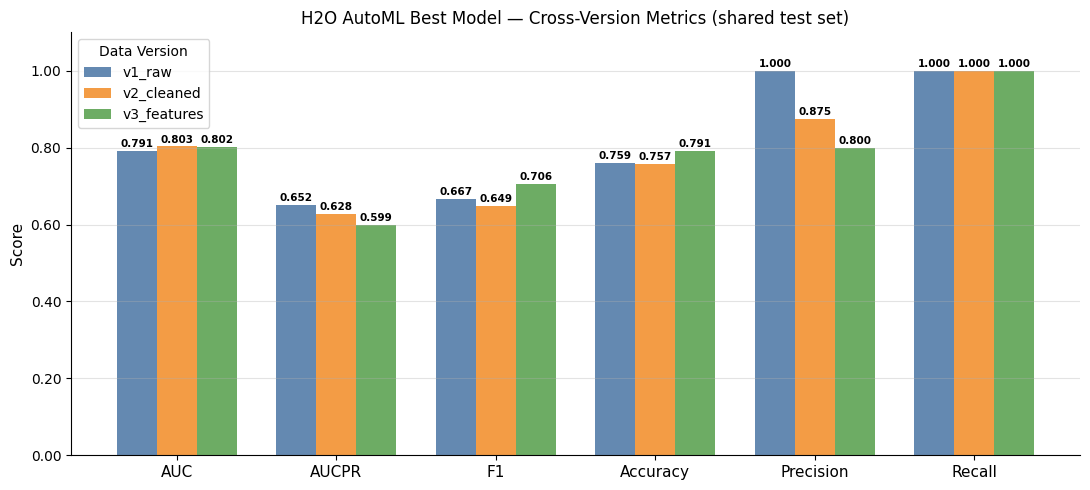

In [10]:
plot_metrics = ['AUC', 'AUCPR', 'F1', 'Accuracy', 'Precision', 'Recall']
versions     = list(summary_df.index)
colors       = ['#4e79a7', '#f28e2b', '#59a14f']
x            = np.arange(len(plot_metrics))
width        = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (ver, color) in enumerate(zip(versions, colors)):
    vals = summary_df.loc[ver, plot_metrics].values.astype(float)
    bars = ax.bar(x + i*width, vals, width, label=ver, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('H2O AutoML Best Model — Cross-Version Metrics (shared test set)', fontsize=12)
ax.legend(title='Data Version', fontsize=10)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.35)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_version_bar.png', dpi=150)
plt.show()

### 8b. ROC Curves — All Three Best Models Overlaid

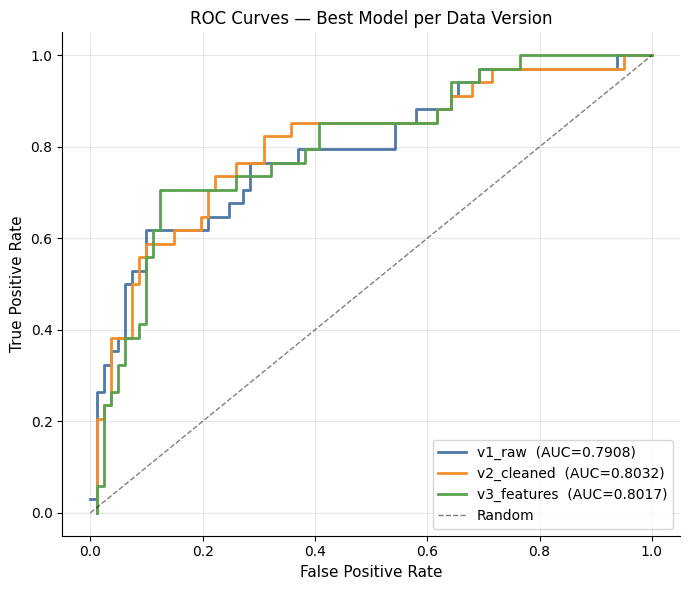

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
colors  = ['#4e79a7', '#f28e2b', '#59a14f']

for (ver, res), color in zip(results.items(), colors):
    perf = res['perf']
    # fprs/tprs are plain Python lists — convert to numpy arrays
    fpr = np.array(perf.fprs)
    tpr = np.array(perf.tprs)
    auc = summary_df.loc[ver, 'AUC']
    ax.plot(fpr, tpr, label=f'{ver}  (AUC={auc})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Best Model per Data Version', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150)
plt.show()

### 8c. Confusion Matrices — Side by Side

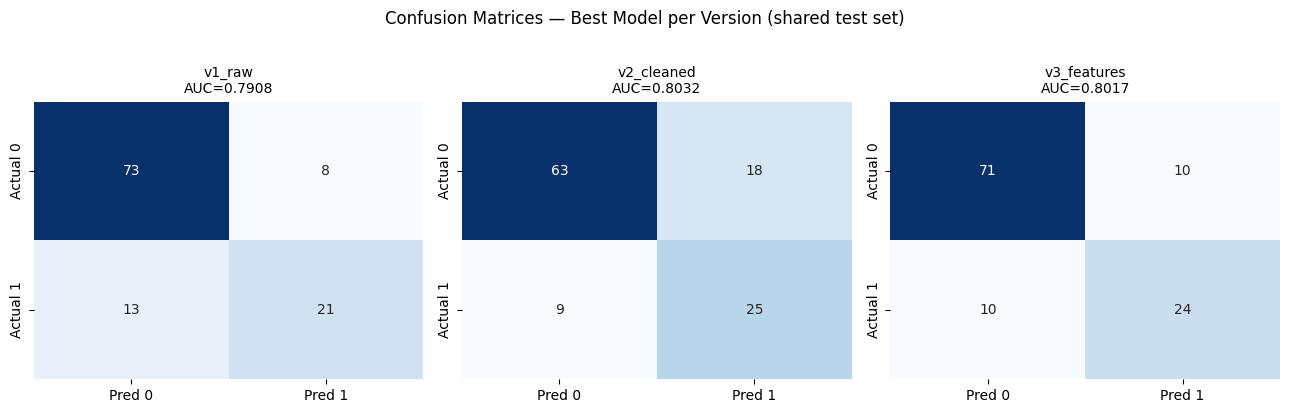

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (ver, res) in zip(axes, results.items()):
    # H2O ConfusionMatrix.table is an H2OTwoDimTable
    # cell_values rows: [label, col0, col1, 'Error', 'Rate']
    # rows 0 = class 0, row 1 = class 1, row 2 = Total
    cv  = res['perf'].confusion_matrix().table.cell_values
    tn  = int(float(cv[0][1]))   # actual=0, pred=0
    fp  = int(float(cv[0][2]))   # actual=0, pred=1
    fn  = int(float(cv[1][1]))   # actual=1, pred=0
    tp  = int(float(cv[1][2]))   # actual=1, pred=1
    cm  = np.array([[tn, fp], [fn, tp]])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['Actual 0','Actual 1'],
                cbar=False)
    auc = summary_df.loc[ver, 'AUC']
    ax.set_title(f'{ver}\nAUC={auc}', fontsize=10)

plt.suptitle('Confusion Matrices — Best Model per Version (shared test set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance per Version

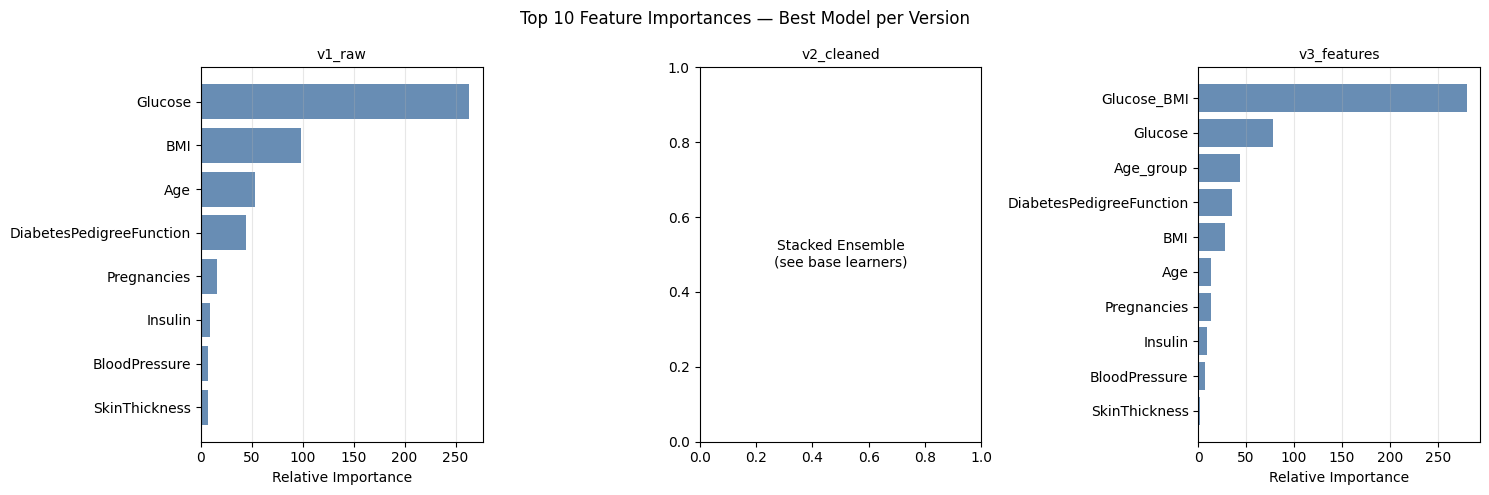

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (ver, res) in zip(axes, results.items()):
    leader = res['aml'].leader
    try:
        fi = leader.varimp(use_pandas=True).head(10)
        ax.barh(fi['variable'][::-1], fi['relative_importance'][::-1],
                color='#4e79a7', alpha=0.85)
        ax.set_title(ver, fontsize=10)
        ax.set_xlabel('Relative Importance')
        ax.grid(axis='x', alpha=0.3)
    except Exception:
        ax.text(0.5, 0.5, 'Stacked Ensemble\n(see base learners)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(ver, fontsize=10)

plt.suptitle('Top 10 Feature Importances — Best Model per Version', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150)
plt.show()

## 10. Save Best Models

In [14]:
for ver, res in results.items():
    path = h2o.save_model(
        model=res['aml'].leader,
        path=str(OUTPUT_DIR / f'best_model_{ver}'),
        force=True,
    )
    print(f'[{ver}] saved -> {path}')

[v1_raw] saved -> /app/h2o_automl_results/best_model_v1_raw/GBM_1_AutoML_1_20260521_205501
[v2_cleaned] saved -> /app/h2o_automl_results/best_model_v2_cleaned/StackedEnsemble_BestOfFamily_1_AutoML_2_20260521_205704
[v3_features] saved -> /app/h2o_automl_results/best_model_v3_features/GBM_1_AutoML_3_20260521_205901
